# Imbalance Analysis

### Imports

In [1]:
import sys
import pandas as pd

### Load Dataset

In [19]:
# Allow the dataset to be loaded with both a Google Colab kernel and a local kernel

# Load the dataset with Google Colab kernel and Drive file
if 'google.colab' in sys.modules:
    # Time (aprox. 25.0s)
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth # type: ignore
    from oauth2client.client import GoogleCredentials

    # Authenticate the User in Google Drive
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Google Drive ID for public sharing of the dataset
    file_id = "1jNCvMvAPawvH8avENiwbYvQReaZOiqMH"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('processed_data.csv')

    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Load the dataset with local kernel and local file
else:
    # Time (13th Gen Intel Core i5-1335U: aprox. 0.5s; AMD Ryzen AI 9 HX 370 (24) @ 5.16 GHz: aprox. 1.0s)
    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("../data/processed/processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Stop Jupyter Notebook from limiting the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Display dataset head
df.head()

,id,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_act_il,il_util,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,acc_open_past_24mths,bc_open_to_buy,bc_util,chargeoff_within_12_mths,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,68407277,3600,False,13.99,123.03,13,10,2,55000.0,2015-12-01,0,2,38,5.91,0,2003-08-01,675,1,30,999,7,0,2765.0,29.7,13.0,False,30,False,0,722.0,144904.0,2,36.0,3,722.0,34.0,9300.0,3,1,4.0,1506.0,37.2,0,148,128,3,3,1,4,69,4,69,2,2,4,2,5,3,4,9,4,7,76.9,0.0,0,0,178050.0,7746.0,2400.0,13734.0
1,68355089,24700,False,11.99,820.28,10,10,2,65000.0,2015-12-01,0,11,41,16.06,1,1999-12-01,715,4,6,999,22,0,21470.0,19.2,38.0,False,999,False,0,0.0,204396.0,1,73.0,3,6472.0,29.0,111800.0,0,0,4.0,57830.0,27.1,0,113,192,2,2,4,2,999,0,6,0,5,5,13,17,6,20,27,5,22,97.4,7.7,0,0,314017.0,39475.0,79300.0,24667.0
2,68341763,20000,True,10.78,432.66,8,10,2,63000.0,2015-12-01,0,4,14,10.78,0,2000-08-01,695,0,999,999,6,0,7869.0,56.2,18.0,False,999,True,0,0.0,189699.0,1,73.0,2,2081.0,65.0,14000.0,2,5,6.0,2737.0,55.9,0,125,184,14,14,5,101,999,10,999,0,2,3,2,4,6,4,7,3,6,100.0,50.0,0,0,218418.0,18696.0,6200.0,14877.0
3,68476807,10400,True,22.45,289.91,25,3,2,104433.0,2015-12-01,0,6,38,25.37,1,1998-06-01,695,3,12,999,12,0,21929.0,64.5,35.0,False,999,False,0,0.0,331730.0,3,84.0,7,9702.0,78.0,34000.0,2,1,10.0,4567.0,77.5,0,128,210,4,4,6,4,12,1,12,0,4,6,5,9,10,7,19,6,12,96.6,60.0,0,0,439570.0,95768.0,20300.0,88097.0
4,68426831,11950,False,13.44,405.18,12,4,1,34000.0,2015-12-01,0,2,10,10.2,0,1987-10-01,690,0,999,999,5,0,8822.0,68.4,6.0,False,999,False,0,0.0,12798.0,1,99.0,0,4522.0,76.0,12900.0,0,0,0.0,844.0,91.0,0,338,54,32,32,0,36,999,999,999,0,2,3,2,2,2,4,4,3,5,100.0,100.0,0,0,16900.0,12798.0,9400.0,4000.0


In [ ]:
# we ensure that imbalanced-learn is installed and import the necessary classes for balancing the dataset.
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline
    print("Librerías de balanceo listas.")
except ImportError:
    print("Instalando imbalanced-learn...")
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline

# define x and y, and split the dataset into training and testing sets 
# with stratification to maintain the original class distribution in the test set.
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Iitinal slipt (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dataset cargado y dividido. Registros en Train: {X_train.shape[0]}")

Librerías de balanceo listas.
Dataset cargado y dividido. Registros en Train: 1103559


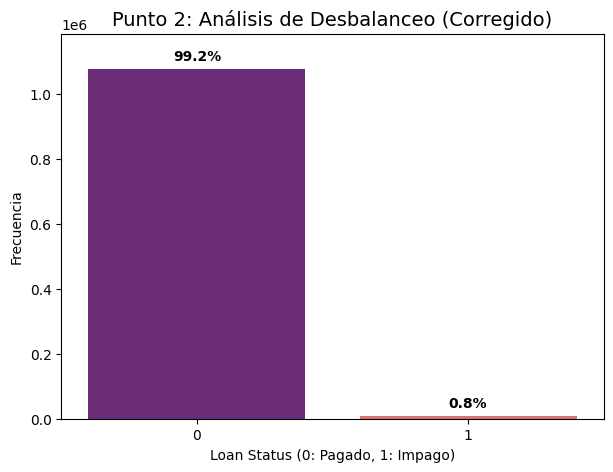

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# We force de dataset to be binary (0 and 1) to avoid issues with Matplotlib and ensure correct percentage calculations.
df = df[df['loan_status'].isin([0, 1])]

# We enssure that its type is integer to prevent Matplotlib from inventing decimals on the X axis.
df['loan_status'] = df['loan_status'].astype(int)

# We recalculate counts and percentages to ensure they are correct for the new binary dataset.
class_counts = df['loan_status'].value_counts().sort_index()
class_pct = df['loan_status'].value_counts(normalize=True).sort_index() * 100

#  We create a bar plot with the new binary dataset, ensuring that percentages are calculated and displayed correctly.
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='magma', legend=False)

plt.title('Imbalance analysis', fontsize=14)
plt.xlabel('Loan Status (0: Pagado, 1: Impago)')
plt.ylabel('Frecuencia')

# Add labels with the correct percentages on top of the bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{class_pct.iloc[i]:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontweight='bold')

plt.ylim(0, max(class_counts.values) * 1.1) # Espacio para el texto
plt.show()

Columnas listas para SMOTE (sin IDs ni Fechas): 64
Aplicando mitigación de desbalanceo... (esto ya no debería fallar)

--- Distribución FINAL ---
Clase 0: 13498 | Clase 1: 13498


C:\Users\inigo.infante\AppData\Local\Temp\ipykernel_24272\1656532730.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_clean.to_numpy(), ax=ax[0], palette='Blues').set_title('Before (unbalanced)')
C:\Users\inigo.infante\AppData\Local\Temp\ipykernel_24272\1656532730.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res.to_numpy(), ax=ax[1], palette='Oranges').set_title('After (balanced)')


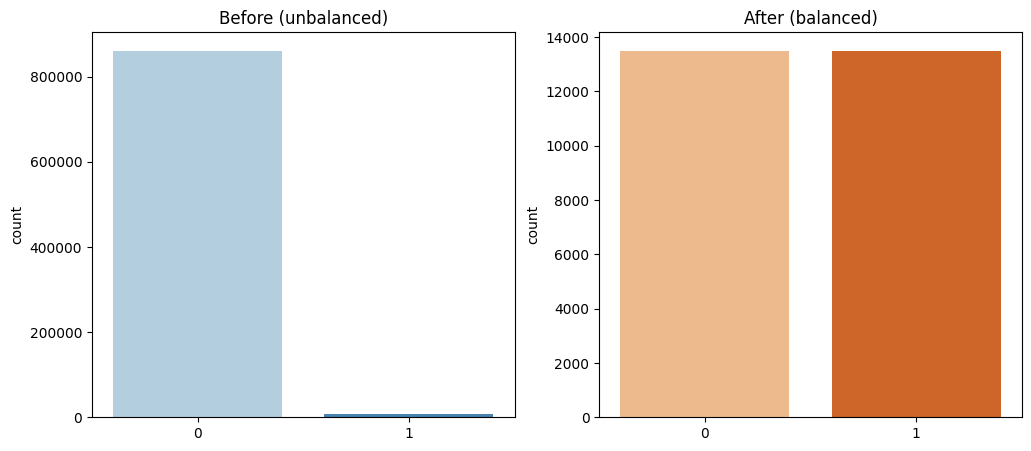

5081

In [ ]:
import gc
import numpy as np
import pandas as pd

mask = (y_train == 0) | (y_train == 1)
X_train_clean = X_train[mask].copy()
y_train_clean = y_train[mask].copy().astype(int)

# DELETE IDs: The ID is not a predictive feature, it's just a label. 
# Also, it can cause memory issues and type errors with SMOTE.

cols_to_drop = ['id'] 
X_train_clean = X_train_clean.drop(columns=[c for c in cols_to_drop if c in X_train_clean.columns])

# We convert dates to numbers if they exist, as SMOTE cannot handle date types.
if 'earliest_cr_line' in X_train_clean.columns:
    X_train_clean['earliest_cr_line'] = pd.to_datetime(X_train_clean['earliest_cr_line'])
    reference_date = pd.to_datetime('2024-01-01') 
    X_train_clean['days_since_first_credit'] = (reference_date - X_train_clean['earliest_cr_line']).dt.days
    X_train_clean = X_train_clean.drop(columns=['earliest_cr_line'])

# We selected only numbers and converted to standard NumPy float64.
X_train_clean = X_train_clean.select_dtypes(include=[np.number]).astype(np.float64)

print(f"Columnas listas para SMOTE (sin IDs ni Fechas): {X_train_clean.shape[1]}")

#Mitigating imbalance with a combined approach: 
# first undersampling the majority class, 
# then applying SMOTE to the minority class.
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
over = SMOTE(sampling_strategy=1.0, random_state=42)
balance_pipe = Pipeline(steps=[('u', under), ('o', over)])

print("Aplicando mitigación de desbalanceo... (esto ya no debería fallar)")
X_train_res, y_train_res = balance_pipe.fit_resample(X_train_clean, y_train_clean)

# Final verification of the new class distribution
final_counts = y_train_res.value_counts()
print(f"\n--- Distribución FINAL ---")
print(f"Clase 0: {final_counts[0]} | Clase 1: {final_counts[1]}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train_clean.to_numpy(), ax=ax[0], palette='Blues').set_title('Before (unbalanced)')
sns.countplot(x=y_train_res.to_numpy(), ax=ax[1], palette='Oranges').set_title('After (balanced)')
plt.show()

gc.collect()

#The new class distribution is now balanced, 
# with approximately equal numbers of samples in each class. 
# This should allow our models to learn from both classes effectively without being biased towards the majority class.

# It also reduces the sample size to a manageable level for SMOTE,
#  preventing memory issues and allowing the algorithm to generate
#  synthetic samples for the minority class without errors.